In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import joblib
import pickle

from flask import Flask, render_template, request


In [2]:
df = pd.read_csv("Dataset/Flood_Prediction_Dataset.csv")

print("First Five Records:")
display(df.head())

print("\nLast Five Records:")
display(df.tail())

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

print("\nData Types:")
print(df.dtypes)


First Five Records:


,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.8667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.3000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.2000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.0667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.4000,586.9,0



Last Five Records:


,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
110,28,71,30,3035.1,66.2,313.5,2209.1,446.3,262.8333,664.3,0
111,29,71,37,2151.1,18.3,287.4,1535.6,309.8,143.4333,335.0,0
112,30,74,42,3255.4,43.9,218.5,2561.2,431.8,347.5667,923.4,1
113,31,71,31,3046.4,14.9,364.5,2164.8,502.1,151.4667,203.4,0
114,28,71,34,2600.6,8.9,465.9,1514.7,611.1,187.8667,361.8,0



Shape of Dataset:
(115, 11)

Column Names:
Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB

Missing Values:
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL     

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100871,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547595,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666700,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033300,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833300,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066700,982.700000,1.000000



Data Types:
Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object


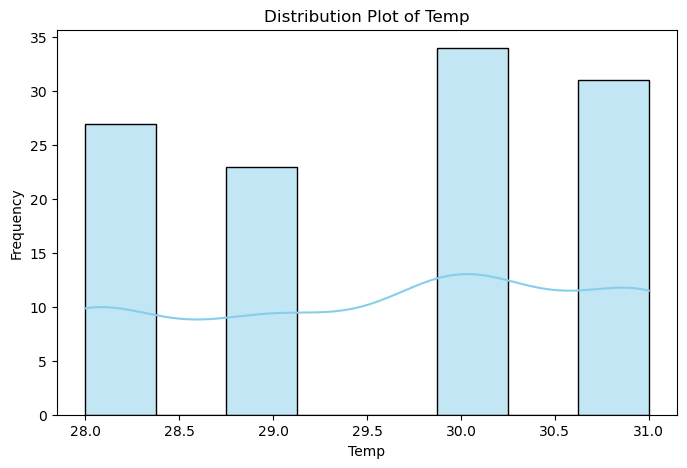

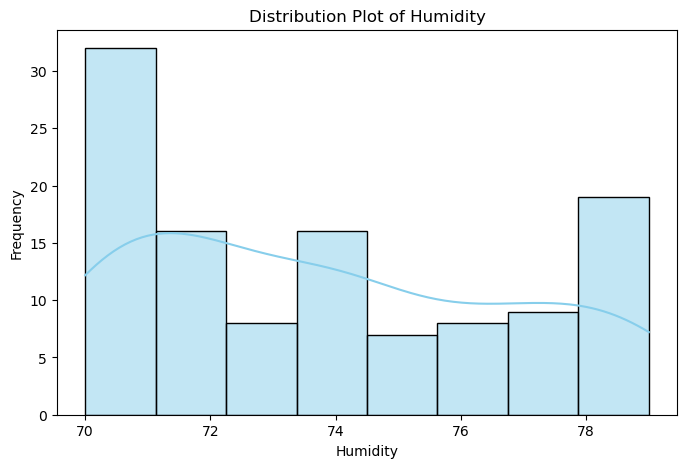

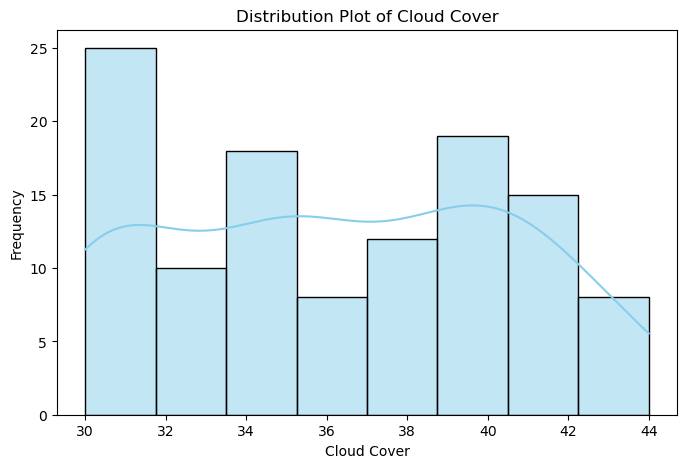

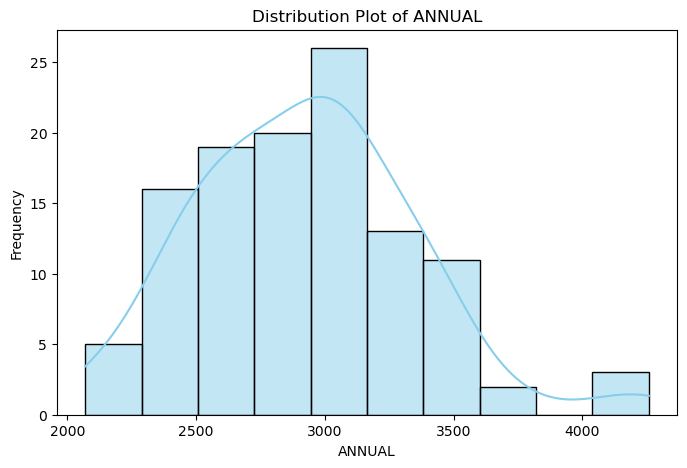

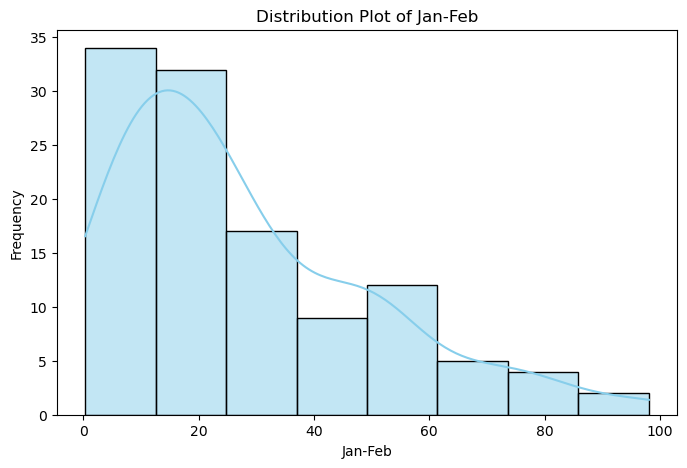

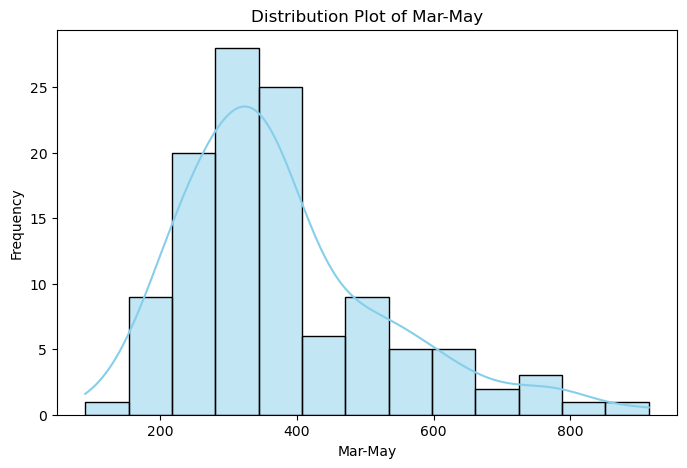

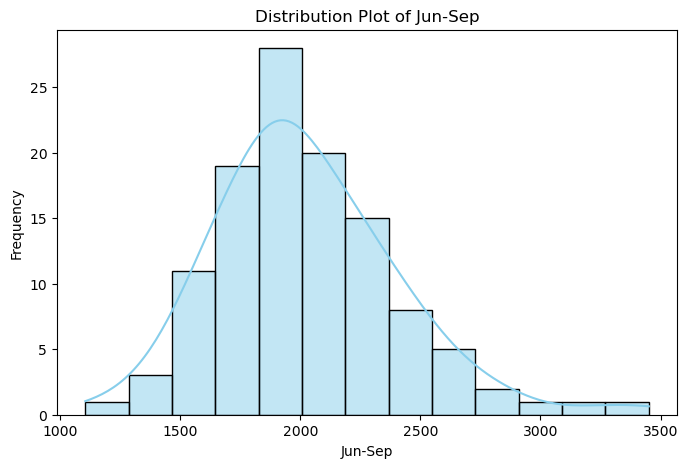

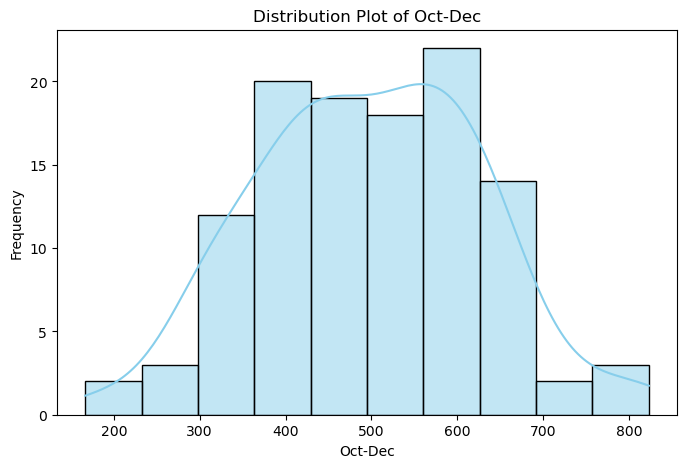

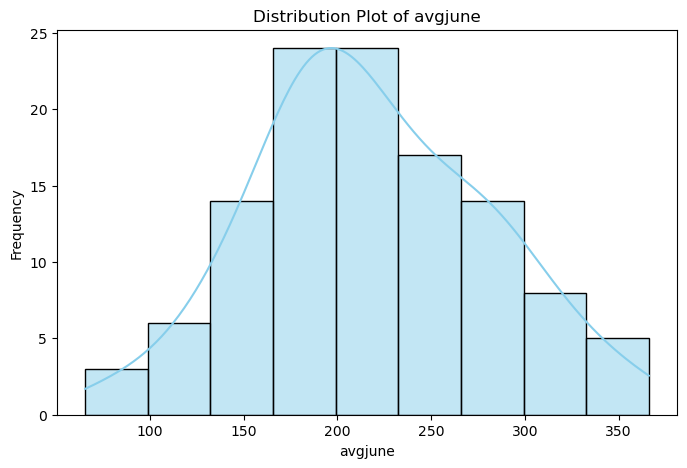

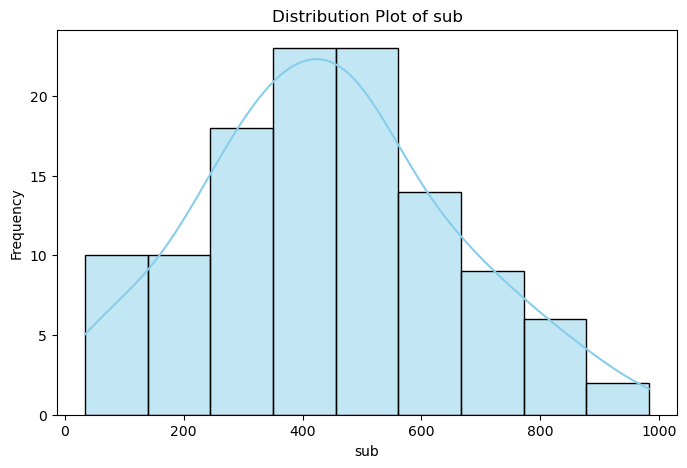

In [3]:
numerical_columns = [
    'Temp',
    'Humidity',
    'Cloud Cover',
    'ANNUAL',
    'Jan-Feb',
    'Mar-May',
    'Jun-Sep',
    'Oct-Dec',
    'avgjune',
    'sub'
]

for column in numerical_columns:
    
    plt.figure(figsize=(8,5))
    
    sns.histplot(df[column], kde=True, color='skyblue')
    
    plt.title(f'Distribution Plot of {column}')
    plt.xlabel(column)
    plt.ylabel("Frequency")
    
    plt.show()
    

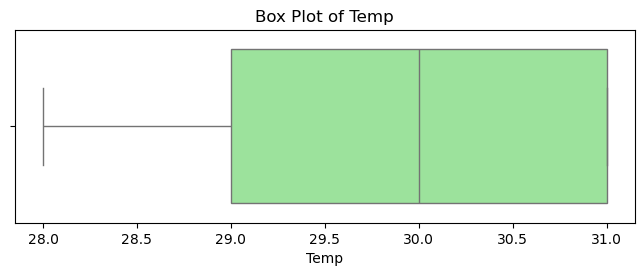

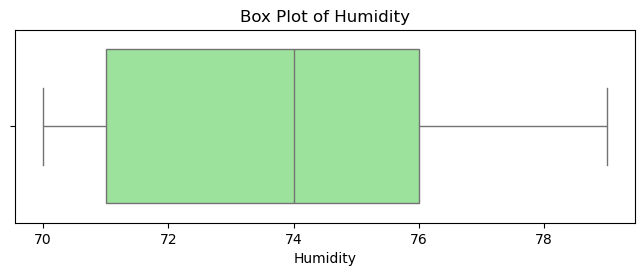

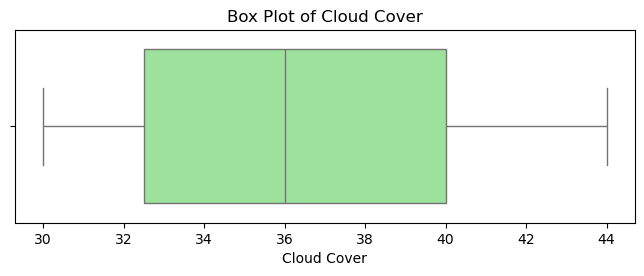

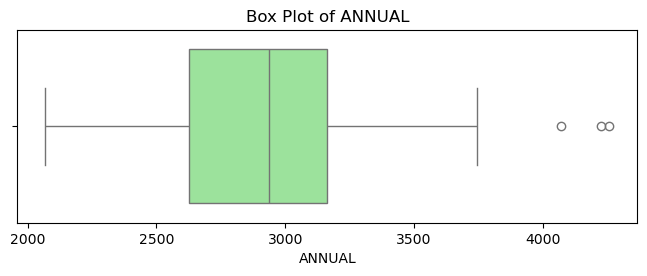

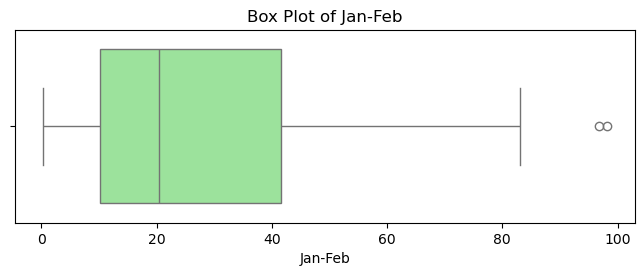

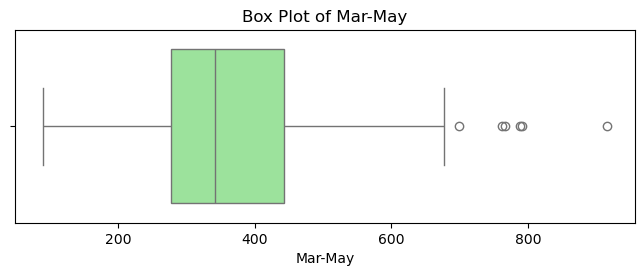

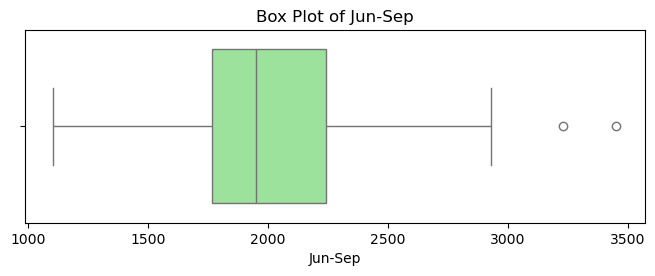

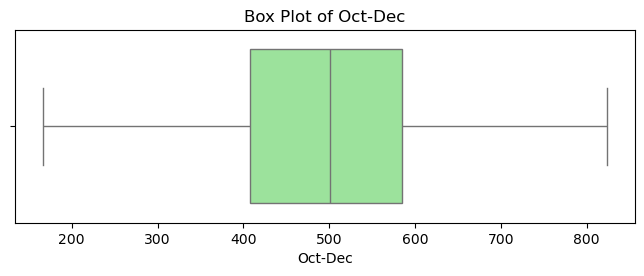

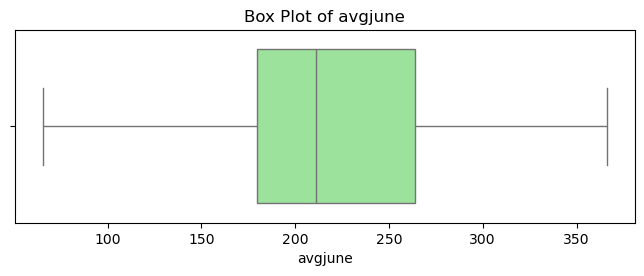

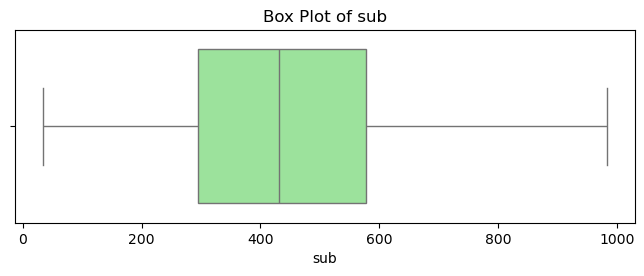

In [4]:
for column in numerical_columns:
    
    plt.figure(figsize=(8,2.5))
    
    sns.boxplot(x=df[column], color='lightgreen')
    
    plt.title(f'Box Plot of {column}')
    
    plt.show()
    

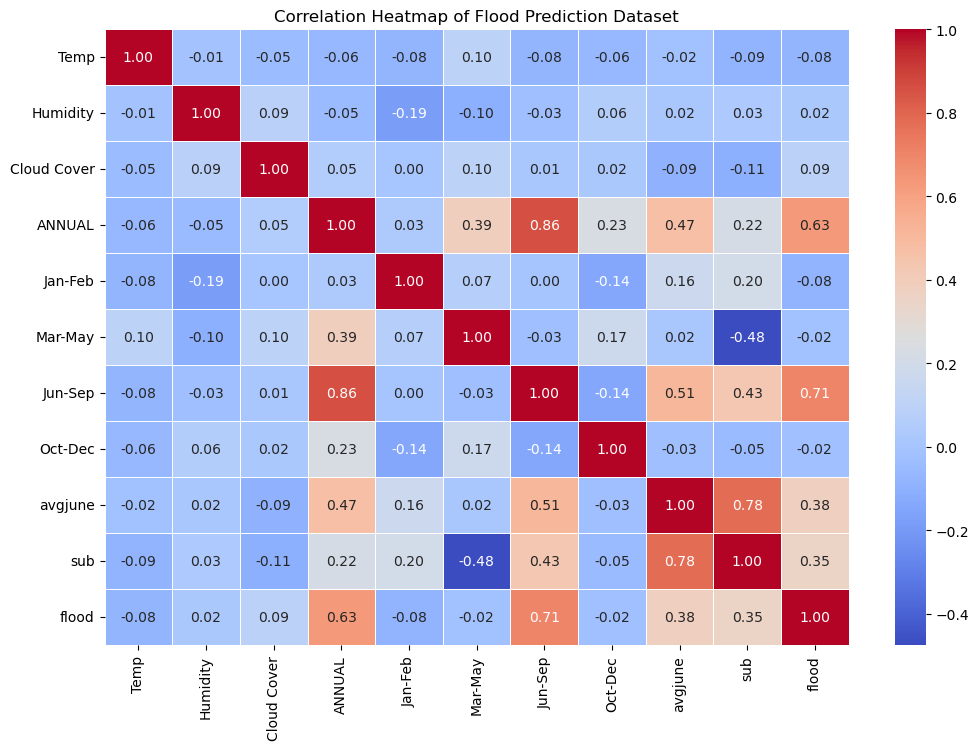

In [5]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Flood Prediction Dataset")

plt.show()


In [6]:
print("First Five Records:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nData Types:")
display(df.dtypes)


First Five Records:


,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.8667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.3000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.2000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.0667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.4000,586.9,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB

Statistical Summary:


,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100871,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547595,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666700,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033300,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833300,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066700,982.700000,1.000000



Data Types:


Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object

In [7]:
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

print("\n" + "="*50)

print("Does the dataset contain any missing values?\n")
print(df.isnull().any())

print("\n" + "="*50)

print("Total Missing Values in Dataset:", df.isnull().sum().sum())


Missing Values in Each Column:

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

Does the dataset contain any missing values?

Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

Total Missing Values in Dataset: 0


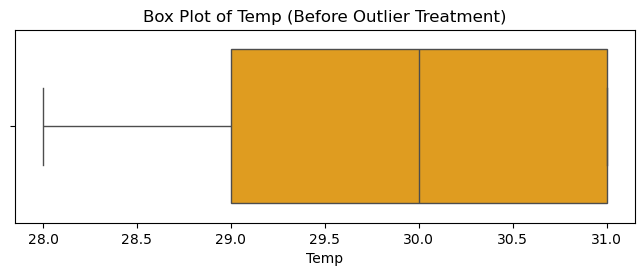

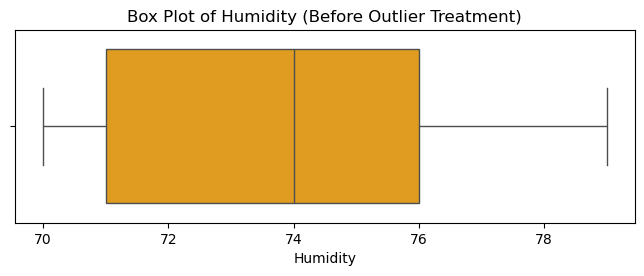

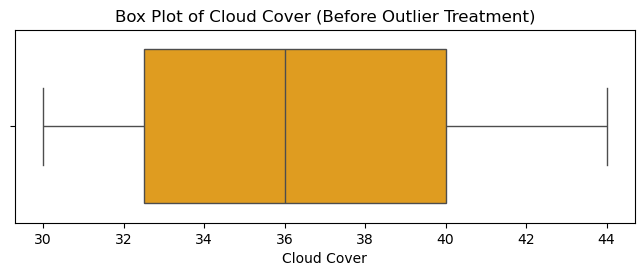

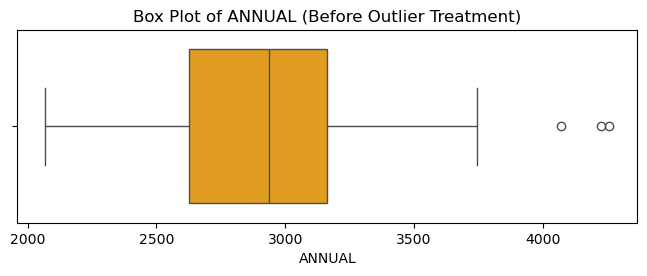

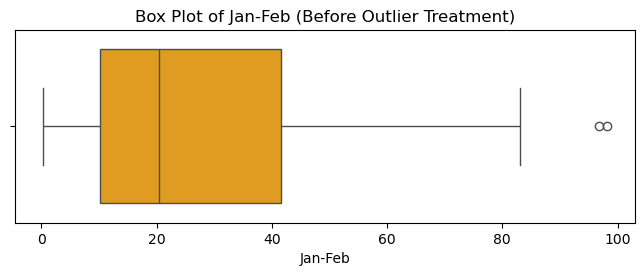

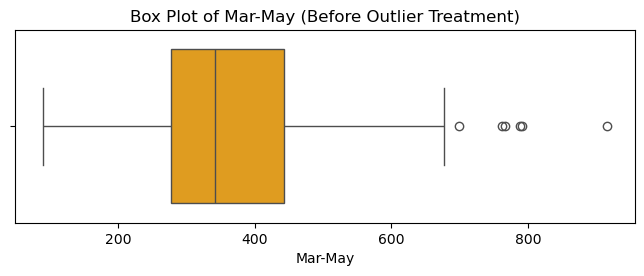

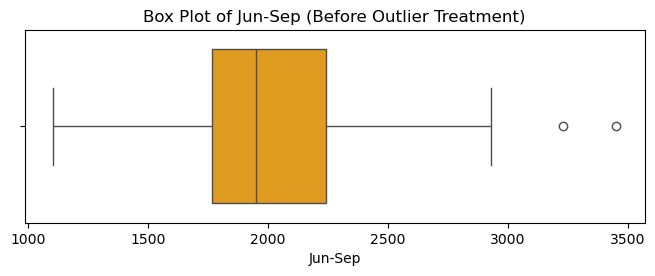

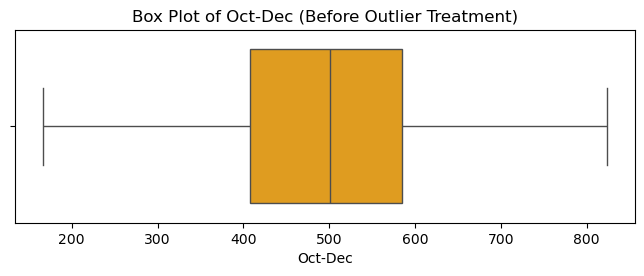

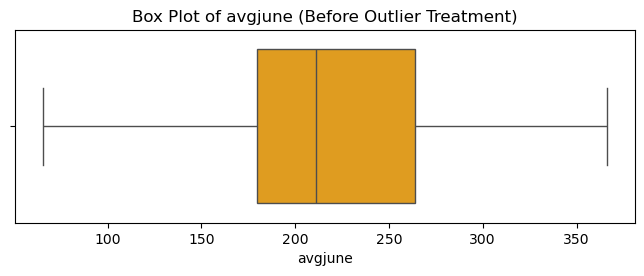

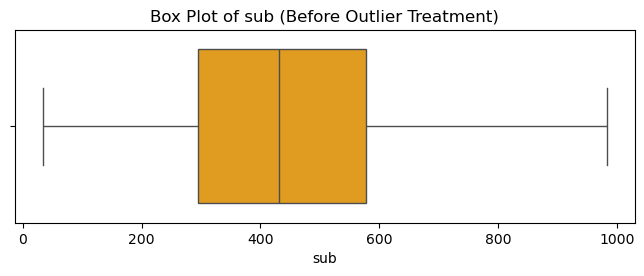

In [8]:
numerical_columns = [
    'Temp',
    'Humidity',
    'Cloud Cover',
    'ANNUAL',
    'Jan-Feb',
    'Mar-May',
    'Jun-Sep',
    'Oct-Dec',
    'avgjune',
    'sub'
]

for column in numerical_columns:

    plt.figure(figsize=(8,2.5))

    sns.boxplot(x=df[column], color='orange')

    plt.title(f'Box Plot of {column} (Before Outlier Treatment)')

    plt.show()
    

In [9]:
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower_limit,
                          lower_limit,
                          df[column])

    df[column] = np.where(df[column] > upper_limit,
                          upper_limit,
                          df[column])

print("Outlier treatment using IQR capping completed successfully.")


Outlier treatment using IQR capping completed successfully.


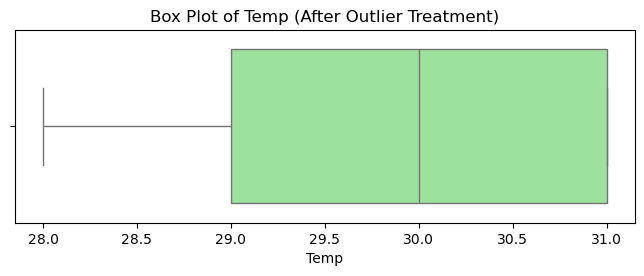

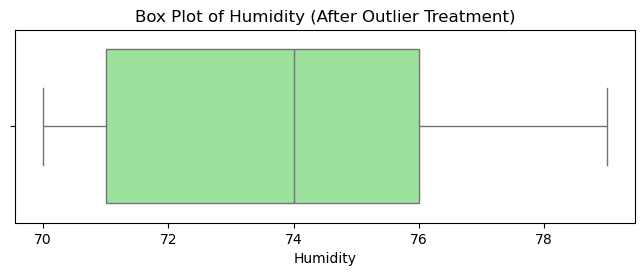

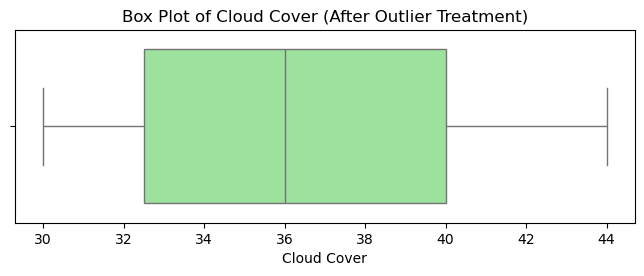

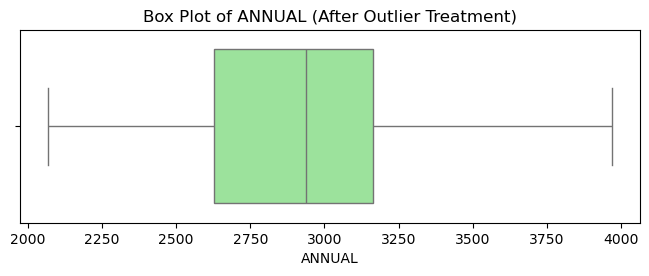

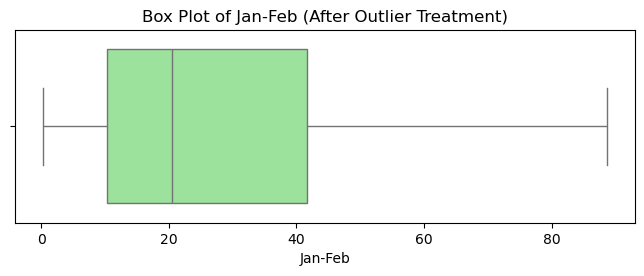

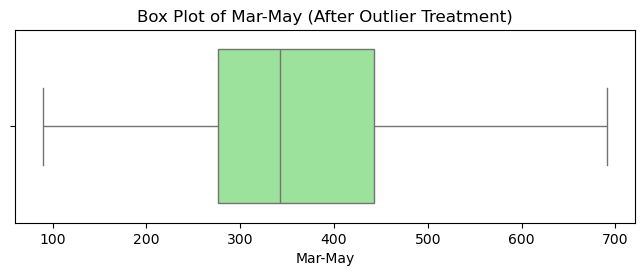

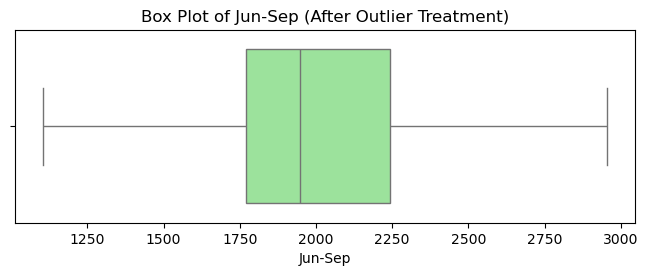

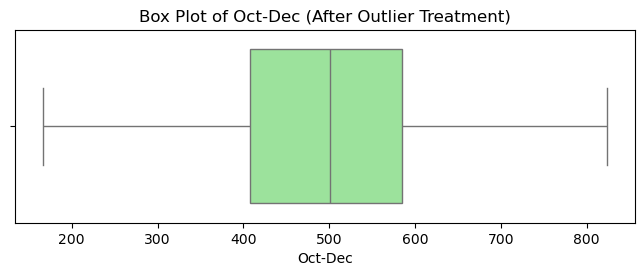

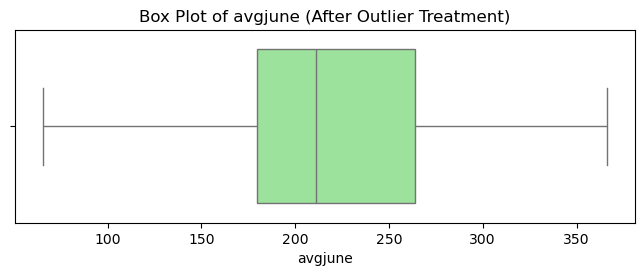

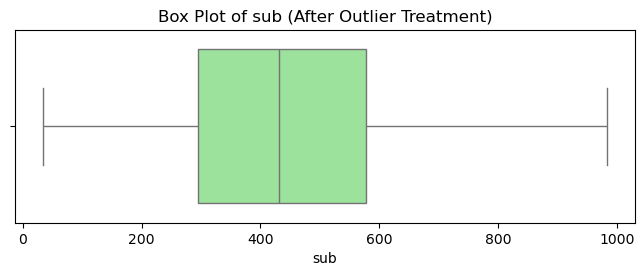

In [10]:
for column in numerical_columns:

    plt.figure(figsize=(8,2.5))

    sns.boxplot(x=df[column], color='lightgreen')

    plt.title(f'Box Plot of {column} (After Outlier Treatment)')

    plt.show()
    

In [11]:
print("Data Types:\n")
print(df.dtypes)

print("\n" + "="*50)

categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

print("\n" + "="*50)

if len(categorical_columns) == 0:
    print("No categorical columns found.")
    print("No Label Encoding or Feature Mapping is required.")
else:
    print("Categorical columns are available and require encoding.")
    

Data Types:

Temp           float64
Humidity       float64
Cloud Cover    float64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object

Categorical Columns:
Index([], dtype='object')

No categorical columns found.
No Label Encoding or Feature Mapping is required.


In [12]:
X = df.iloc[:, :-1].values

y = df.iloc[:, -1].values

print("Independent Features Shape:", X.shape)
print("Dependent Feature Shape:", y.shape)


Independent Features Shape: (115, 10)
Dependent Feature Shape: (115,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("Training Feature Set :", X_train.shape)
print("Testing Feature Set  :", X_test.shape)
print("Training Target Set  :", y_train.shape)
print("Testing Target Set   :", y_test.shape)


Training Feature Set : (92, 10)
Testing Feature Set  : (23, 10)
Training Target Set  : (92,)
Testing Target Set   : (23,)


In [16]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

print("Feature Scaling completed successfully.")


Feature Scaling completed successfully.


In [17]:
import joblib

joblib.dump(sc, "scaler.pkl")

print("Scaler saved successfully.")


Scaler saved successfully.


In [18]:
def decisiontree(X_train, X_test, y_train, y_test):

    from sklearn.tree import DecisionTreeClassifier

    dtree = DecisionTreeClassifier(random_state=42)

    dtree.fit(X_train, y_train)

    y_pred = dtree.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Decision Tree Accuracy :", round(accuracy * 100, 2), "%")

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return dtree, accuracy
    

In [19]:
dt_model, dt_accuracy = decisiontree(
    X_train,
    X_test,
    y_train,
    y_test
)


Decision Tree Accuracy : 100.0 %

Confusion Matrix:

[[20  0]
 [ 0  3]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [20]:
def randomForest(X_train, X_test, y_train, y_test):

    from sklearn.ensemble import RandomForestClassifier

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Random Forest Accuracy :", round(accuracy * 100, 2), "%")

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return rf, accuracy
    

In [21]:
rf_model, rf_accuracy = randomForest(
    X_train,
    X_test,
    y_train,
    y_test
)


Random Forest Accuracy : 100.0 %

Confusion Matrix:

[[20  0]
 [ 0  3]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [22]:
def KNN(X_train, X_test, y_train, y_test):

    from sklearn.neighbors import KNeighborsClassifier

    knn = KNeighborsClassifier(n_neighbors=5)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("KNN Accuracy :", round(accuracy * 100, 2), "%")

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return knn, accuracy
    

In [23]:
knn_model, knn_accuracy = KNN(
    X_train,
    X_test,
    y_train,
    y_test
)


KNN Accuracy : 91.3 %

Confusion Matrix:

[[20  0]
 [ 2  1]]

Classification Report:

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       1.00      0.33      0.50         3

    accuracy                           0.91        23
   macro avg       0.95      0.67      0.73        23
weighted avg       0.92      0.91      0.89        23



In [24]:
def XGBoost(X_train, X_test, y_train, y_test):

    from xgboost import XGBClassifier

    xgb = XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    xgb.fit(X_train, y_train)

    y_pred = xgb.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("XGBoost Accuracy :", round(accuracy * 100, 2), "%")

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return xgb, accuracy
    

In [25]:
xgb_model, xgb_accuracy = XGBoost(
    X_train,
    X_test,
    y_train,
    y_test
)


XGBoost Accuracy : 100.0 %

Confusion Matrix:

[[20  0]
 [ 0  3]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [26]:
model_accuracy = {
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy,
    "XGBoost": xgb_accuracy
}

comparison = pd.DataFrame(
    model_accuracy.items(),
    columns=["Model", "Accuracy"]
)

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

print("Model Comparison:\n")

display(comparison[["Model", "Accuracy (%)"]])


Model Comparison:



,Model,Accuracy (%)
0,Decision Tree,100.000000
1,Random Forest,100.000000
2,KNN,91.304348
3,XGBoost,100.000000


In [29]:
print("Final Selected Model : XGBoost")

print("Accuracy :", round(xgb_accuracy * 100, 2), "%")


Final Selected Model : XGBoost
Accuracy : 100.0 %


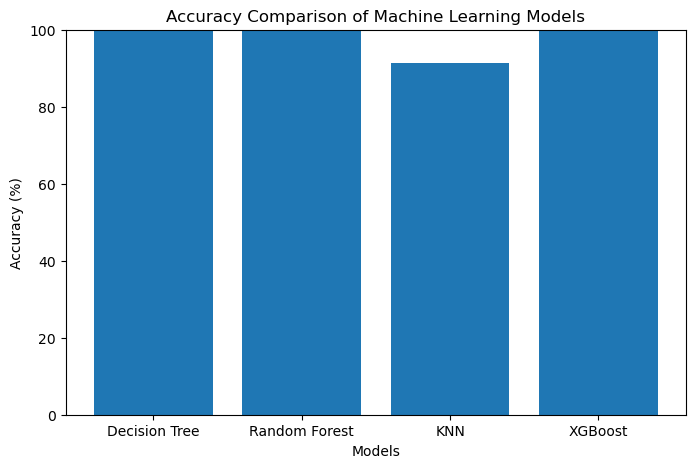

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

plt.ylim(0,100)

plt.show()


In [30]:
y_pred = xgb_model.predict(X_test)

print("Accuracy Score :",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("Precision Score :",
      round(precision_score(y_test, y_pred), 4))

print("Recall Score :",
      round(recall_score(y_test, y_pred), 4))

print("F1 Score :",
      round(f1_score(y_test, y_pred), 4))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy Score : 100.0 %
Precision Score : 1.0
Recall Score : 1.0
F1 Score : 1.0

Confusion Matrix:

[[20  0]
 [ 0  3]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [31]:
import joblib

joblib.dump(xgb_model, "floods.save")

joblib.dump(sc, "transform.save")

print("Model saved as floods.save")
print("Scaler saved as transform.save")


Model saved as floods.save
Scaler saved as transform.save
